In [47]:
import pandas as pd
import numpy as np


In [48]:
df = pd.read_csv('Fast Delivery Agent Reviews.csv')

In [49]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Agent Name               5000 non-null   object 
 1   Rating                   5000 non-null   float64
 2   Review Text              5000 non-null   object 
 3   Delivery Time (min)      5000 non-null   int64  
 4   Location                 5000 non-null   object 
 5   Order Type               5000 non-null   object 
 6   Customer Feedback Type   5000 non-null   object 
 7   Price Range              5000 non-null   object 
 8   Discount Applied         5000 non-null   object 
 9   Product Availability     5000 non-null   object 
 10  Customer Service Rating  5000 non-null   int64  
 11  Order Accuracy           5000 non-null   object 
dtypes: float64(1), int64(2), object(9)
memory usage: 468.9+ KB


In [50]:
df.head()

,Agent Name,Rating,Review Text,Delivery Time (min),Location,Order Type,Customer Feedback Type,Price Range,Discount Applied,Product Availability,Customer Service Rating,Order Accuracy
0,Zepto,4.5,Purpose boy job cup decision girl now get job ...,58,Delhi,Essentials,Neutral,High,Yes,Out of Stock,4,Incorrect
1,Zepto,2.1,Prevent production able both the box school wa...,25,Lucknow,Grocery,Negative,Low,No,Out of Stock,2,Correct
2,JioMart,4.5,Family station listen agreement more kitchen l...,54,Ahmedabad,Essentials,Neutral,Low,No,Out of Stock,3,Correct
3,JioMart,2.6,World north people area everything enter beyon...,22,Chennai,Essentials,Neutral,Low,Yes,In Stock,1,Incorrect
4,Zepto,3.6,Hand way yourself tax whether sister anyone ef...,34,Pune,Pharmacy,Positive,High,No,In Stock,2,Incorrect


In [51]:
df.describe()

,Rating,Delivery Time (min),Customer Service Rating
count,5000.00000,5000.000000,5000.000000
mean,3.00290,34.962400,2.972000
std,1.15214,14.789656,1.409969
min,1.00000,10.000000,1.000000
25%,2.00000,22.000000,2.000000
50%,3.00000,35.000000,3.000000
75%,4.00000,48.000000,4.000000
max,5.00000,60.000000,5.000000


In [52]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ','_').str.replace('(',' ').str.replace(')',' ')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   agent_name               5000 non-null   object 
 1   rating                   5000 non-null   float64
 2   review_text              5000 non-null   object 
 3   delivery_time_ min       5000 non-null   int64  
 4   location                 5000 non-null   object 
 5   order_type               5000 non-null   object 
 6   customer_feedback_type   5000 non-null   object 
 7   price_range              5000 non-null   object 
 8   discount_applied         5000 non-null   object 
 9   product_availability     5000 non-null   object 
 10  customer_service_rating  5000 non-null   int64  
 11  order_accuracy           5000 non-null   object 
dtypes: float64(1), int64(2), object(9)
memory usage: 468.9+ KB


In [53]:
df['agent_name'] = df['agent_name'].str.strip()
df['agent_name'] = df['agent_name'].str.title()
print(df['agent_name'].unique())

['Zepto' 'Jiomart' 'Blinkit' 'Swiggy Instamart']


In [54]:
categorical_col = ['location', 
    'order_type', 
    'customer_feedback_type', 
    'price_range', 
    'discount_applied', 
    'product_availability', 
    'order_accuracy']
for col in categorical_col:
    df[col] = df[col].astype(str).str.strip().str.title()
df['location'].unique() 


array(['Delhi', 'Lucknow', 'Ahmedabad', 'Chennai', 'Pune', 'Jaipur',
       'Mumbai', 'Kolkata', 'Hyderabad', 'Bangalore'], dtype=object)

In [55]:
df['order_accuracy'].value_counts()

order_accuracy
Correct      2515
Incorrect    2485
Name: count, dtype: int64

In [56]:
#Exploratory Data Analysis (EDA) stage in Python.
# ANALYSIS 1: Comparing  Ratings across Delivery Platforms

customer_ratings = (df.groupby('agent_name')['rating'].agg(total_orders = 'count', 
avg_rating = 'mean', median_rating = 'median', rating_std = 'std').round(2).reset_index())
print(customer_ratings)

         agent_name  total_orders  avg_rating  median_rating  rating_std
0           Blinkit          1272        2.99            3.0        1.19
1           Jiomart          1224        2.99            3.0        1.13
2  Swiggy Instamart          1222        3.02            3.0        1.14
3             Zepto          1282        3.01            3.0        1.14


In [57]:
# ANALYSIS 2: Customer service ratings across diffirent order type.
rating_ordertype = (df.groupby('order_type')['customer_service_rating'].agg(total_orders = 'count').round().reset_index())
print(rating_ordertype)


    order_type  total_orders
0  Electronics          1008
1   Essentials          1001
2         Food          1003
3      Grocery           995
4     Pharmacy           993


In [58]:
# ANALYSIS 3: Discount given by location.

#  Cross-tabulation of Location vs Discount Applied

# 1. Total count of Yes vs No per location
discount_counts = pd.crosstab(df['location'], df['discount_applied'], margins=True)

# 2. Percentage (%) breakdown per location
discount_pct = (pd.crosstab(df['location'], df['discount_applied'], normalize='index') * 100).round(2)

print(discount_counts)

print(discount_pct)
                 

discount_applied    No   Yes   All
location                          
Ahmedabad          269   246   515
Bangalore          236   277   513
Chennai            217   261   478
Delhi              248   266   514
Hyderabad          262   228   490
Jaipur             233   256   489
Kolkata            249   268   517
Lucknow            227   244   471
Mumbai             257   241   498
Pune               265   250   515
All               2463  2537  5000
discount_applied     No    Yes
location                      
Ahmedabad         52.23  47.77
Bangalore         46.00  54.00
Chennai           45.40  54.60
Delhi             48.25  51.75
Hyderabad         53.47  46.53
Jaipur            47.65  52.35
Kolkata           48.16  51.84
Lucknow           48.20  51.80
Mumbai            51.61  48.39
Pune              51.46  48.54


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

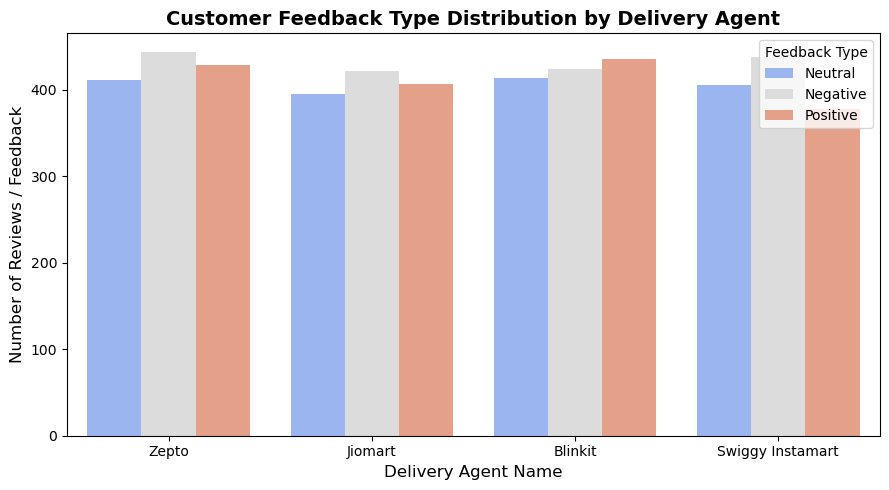

In [41]:
# ANALYSIS 3 : Plot Feedback Breakdown by Delivery Agent

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df, 
    x='agent_name', 
    hue='customer_feedback_type', 
    palette='coolwarm'
)

plt.title('Customer Feedback Type Distribution by Delivery Agent', fontsize=14, fontweight='bold')
plt.xlabel('Delivery Agent Name', fontsize=12)
plt.ylabel('Number of Reviews / Feedback', fontsize=12)
plt.legend(title='Feedback Type')

plt.tight_layout()
plt.show()

In [60]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace('(', '')
    .str.replace(')', '')
    .str.replace(' ', '_')
    .str.replace(r'_+', '_', regex=True) # Replaces '__' with '_'
    .str.strip('_')                   
)
print(df.columns.tolist())

['agent_name', 'rating', 'review_text', 'delivery_time_min', 'location', 'order_type', 'customer_feedback_type', 'price_range', 'discount_applied', 'product_availability', 'customer_service_rating', 'order_accuracy']


In [61]:
# ANALYSIS 4: Delivery Speed Performance across Platforms

delivery_stats = (
    df.groupby('agent_name')['delivery_time_min']
    .agg(
        avg_delivery_time='mean',
        median_delivery_time='median',
        fastest_delivery='min',
        slowest_delivery='max'
    )
    .round(2)
    .reset_index()
)

print("--- Delivery Time Performance (in Minutes) ---")
print(delivery_stats)

--- Delivery Time Performance (in Minutes) ---
         agent_name  avg_delivery_time  median_delivery_time  \
0           Blinkit              34.65                  35.0   
1           Jiomart              35.03                  35.0   
2  Swiggy Instamart              35.12                  35.0   
3             Zepto              35.06                  35.0   

   fastest_delivery  slowest_delivery  
0                10                60  
1                10                60  
2                10                60  
3                10                60  


In [64]:
# ANALYSIS 5: Operational Error Rates (% Incorrect & Out of Stock)

# 1. Calculate percentage of Order Accuracy per agent
accuracy_pct = pd.crosstab(df['agent_name'], df['order_accuracy'], normalize='index') * 100

# 2. Calculate percentage of Product Availability per agent
stock_pct = pd.crosstab(df['agent_name'], df['product_availability'], normalize='index') * 100

# 3. Combine into a clean Operational Summary Table
ops_summary = pd.DataFrame({
    'Incorrect_Order_%': accuracy_pct['Incorrect'].round(2),
    'Out_Of_Stock_%': stock_pct['Out Of Stock'].round(2)
}).reset_index()

print(" Operational Error Rate Breakdown ")
print(ops_summary)

# 4. Save the fully cleaned dataset as a CSV for MySQL importing
df.to_csv('cleaned_fast_delivery_reviews.csv', index=False)
print("\n Cleaned dataset saved as 'cleaned_fast_delivery_reviews.csv' successfully!")


 Operational Error Rate Breakdown 
         agent_name  Incorrect_Order_%  Out_Of_Stock_%
0           Blinkit              49.84           50.08
1           Jiomart              51.14           49.67
2  Swiggy Instamart              50.08           51.55
3             Zepto              47.82           48.99

 Cleaned dataset saved as 'cleaned_fast_delivery_reviews.csv' successfully!
